## Lecture 8 Text Analysis II: Word frequency and word cloud

In the second part of text analysis, we focus on the overview of a collection of documents, and compairson between different parts of a collection of documents. This introduces us two techniques: Word cloud and topic modeling.

**We continue to use the MoFA conference data for this lecture.** For more information about the data, see the notes for the last lecture.

**Table of Content**

1. Drawing word clouds using word frequencies

2. Plotting word frequencies

3. BoW model and tranformation


### 1. Drawing Word Clouds using Word Frequencies

Words are the basic units of documents. More frequent words may tell us more about the main content of the corpus. We are interested in what those frequent words are and how frequent they are. However, there are some pre-processings that we need to do before we get the frequency of substantively meaningful words. This includes:

* Removing stopwords, such as "the", "a", "and", "of", "for".

* Removing punctuations.

* Lemmatization: Converting morphologically inflected words back to their basic form, such as "eaten" to "eat".

* Removing other irrelevant words based on part-of-speech.

* Or, manually removing less interesting words based on researcher's judgement.

**Removing stopwords**

First, let's examine the most frequent words and see how many of the words are basically meaningless.

In [ ]:
text_ling.token.value_counts().head(20)

,count
token,
the,7037
.,3521
to,3148
?,2923
of,2815
China,2800
",",2735
and,2598
’s,2162


There are a lot of "the", "to", "of", and punctuations. They are not helpful for us to understand what does the document mean. We need to remove them. SpaCy can help us too.

**Customized stopwords**

Think about what words are also essentially stopwords for our analysis? For example, "China". Since we are dealing with Chinese MoFA corpus, China must be a word that is super frequent in the corpus. If you have a specific question in mind, you might need to remove words like "China" as well.

1. Filter out stopwords identified by SpaCy.

In [ ]:
text_ling.loc[text_ling.stopword == False, ].token.value_counts().head(20)

,count
token,
.,3521
?,2923
China,2800
",",2735
-,1027
comment,944
Chinese,718
said,705
President,460


2. Remove punctuations.

Since there are still quite many punctuations, we further modify our filtering conditions.

In [ ]:
text_ling.\
  loc[(text_ling.stopword == False) & (text_ling.pos != "PUNCT"), ].\
  token.value_counts().\
  head(20)

,count
token,
China,2800
comment,944
Chinese,718
said,705
President,460
visit,451
foreign,415
ministry,340
Minister,327


3. Lemmatization

Now the frequency table looks pretty good. But we notice that a lot of words are not in their basic forms, such as "said", and "countries". This will make the frequency inaccurate, since "say" and "said" are treated as two different words.

In [ ]:
text_ling.\
  loc[(text_ling.stopword == False) & (text_ling.pos != "PUNCT"), ].\
  lemma.value_counts().\
  head(20)

,count
lemma,
China,2796
comment,1034
say,817
chinese,653
report,641
visit,533
President,460
country,422
foreign,418


4. Draw word cloud.

Now, after you are familiar with the process of removing these meaningless elements, we can make the process nicer, but the order of removal is a bit different.

* Create a df containing the lemmas.

* Filter out stopwords and punctuations.

* Decide the number of most frequent words tobe drawn.

* Create a dictionary with lemmas as key, and count as values.

* Draw the word clouds using WordCloud

In [ ]:
# Create a df that has the lemmas, and their properties in terms of pos, stopwords, and count.
word_frequency = text_ling.loc[:, ['lemma', 'pos', 'stopword']].value_counts().reset_index()

In [ ]:
word_frequency

,lemma,pos,stopword,count
0,the,DET,True,7771
1,.,PUNCT,False,3521
2,?,PUNCT,False,2922
3,of,ADP,True,2812
4,China,PROPN,False,2796
...,...,...,...,...
7378,emphasise,VERB,False,1
7379,empire,NOUN,False,1
7380,empower,VERB,False,1
7381,en,ADP,False,1


In [ ]:
# Filter out stopwords
word_frequency = word_frequency.loc[word_frequency.stopword == False, :]

In [ ]:
# Filter out punctuations
word_frequency = word_frequency.loc[word_frequency.pos != "PUNCT"]

In [ ]:
# The first 100 words will be drawn, but we can update the number however we want.
word_frequency = word_frequency.head(100)

In [ ]:
# Let's examine the dataframe
word_frequency

,lemma,pos,stopword,count
4,China,PROPN,False,2796
19,comment,NOUN,False,985
24,say,VERB,False,817
29,chinese,ADJ,False,653
36,President,PROPN,False,460
...,...,...,...,...
174,Road,PROPN,False,80
175,situation,NOUN,False,80
176,diplomatic,ADJ,False,78
177,New,PROPN,False,78


Now this looks pretty good. Let's convert to a dictionary with "lemma" as key and "count" as values.

In [ ]:
word_frequency_dict = word_frequency.loc[:, ['lemma', 'count']].\
  set_index('lemma').\
  to_dict()['count']

Import the libraries required.

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Draw the word cloud. Run it a couple of times. What happens?

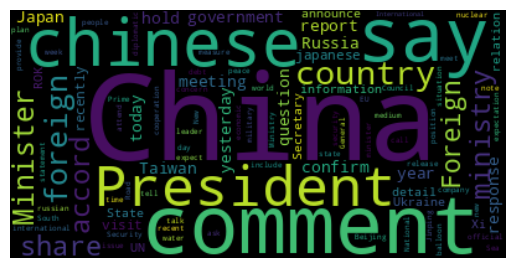

In [ ]:
wordcloud = WordCloud()
wordcloud.generate_from_frequencies(word_frequency_dict)
plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

Each time you execute that chunk of code, it gives you a different word cloud. That is because WordCloud generates a random state each time it is executed. To make the word cloud same, you can specify an argument of "random_state". See the codes below.

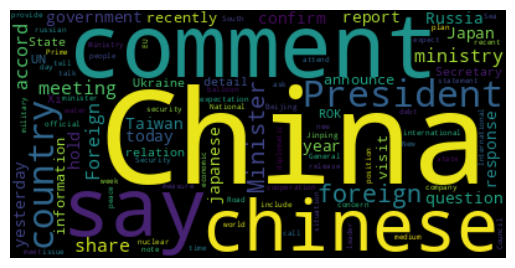

In [ ]:
wordcloud = WordCloud(random_state = 0) # An argument of random_state.
wordcloud.generate_from_frequencies(word_frequency_dict)
plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

Another customization we can make is to change the background color to white, by, again, passing in a argument of background_color.

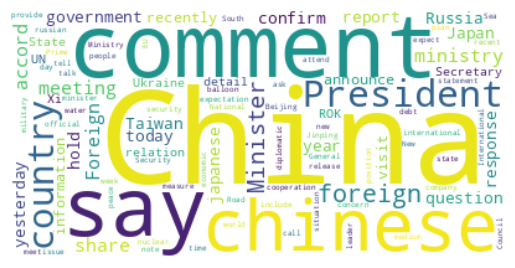

In [ ]:
wordcloud = WordCloud(background_color = "white", random_state = 0)
wordcloud.generate_from_frequencies(word_frequency_dict)
plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

If you feel that the word cloud is very blurry, it is true. You can change that by passing in another pair of arguments of "width" and "height" (in terms of pixels).

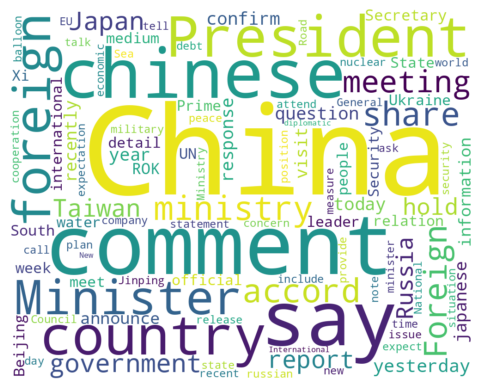

In [ ]:
wordcloud = WordCloud(width = 1000, height = 800,
                      background_color = "white", random_state = 0)
wordcloud.generate_from_frequencies(word_frequency_dict)
plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

There are also several color schemes that we can use. For example, "plasma".

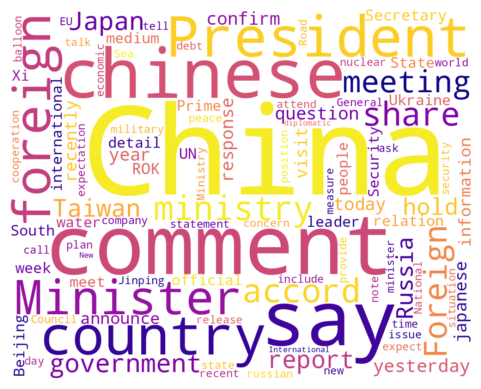

In [ ]:
wordcloud = WordCloud(width = 1000, height = 800,
                      background_color = "white",
                      colormap = "plasma",
                      random_state = 0)
wordcloud.generate_from_frequencies(word_frequency_dict)
plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

If you want to further customize the appearance of your word cloud, you can check out this official documentation:
https://amueller.github.io/word_cloud/auto_examples/index.html#example-gallery

But don’t get too obsessed by the aesthetic designs. Afterall, the most important thing of data visualization is delivering the message. All other aesthetics are secondary.

### 2. Plotting Word Frequency

**A Few Words about the Bag-of-words model**

* “The bag-of-words model (BoW) is a model of text which uses a representation of text that is based on an unordered collection (a "bag") of words.” (from [Wikipedia](https://en.wikipedia.org/wiki/Bag-of-words_model))

* A “bag-of-words” approach is a category of text analysis model that, in the model, disregard the order of words

* Our descriptive analysis using Word Frequency and Word Cloud implicitly uses a BoW assumption

* Topic Modeling, which we are discussing next, is a BoW model

A necessary step before implementing a BoW model is to turn texts into numbers. The kind of input for the topic modeling process is a sentence-word matrix, where each sentence is a row and each word appearing in the collection of all sentences is a column. We will cover more about this later. First, let's talk about the general steps to turn texts to data for BoW models.

* Step 1: Load raw text (DONE in previous steps)

* Step 2: Extract linguistic features from raw text (DONE in previous steps)

* Raw text are turned into a long table, where each row is a word

* Step 3: Select and filter only the relevant linguistic features, including selecting lower case or lemmatized words and removing stop words, punctuations, other less relevant words.

* Step 4: Turn selected linguistic features into data whose formats are acceptable by the BoW model of your choice

We will start from Step 3.

In [ ]:
text_ling_s = text_ling.loc[(~text_ling.pos.isin(['X', 'PUNCT', 'NUM'])) &
  (text_ling.stopword == False), :]
text_ling_s


,token,lower,lemma,pos,stopword,id
3,New,new,New,PROPN,False,28449
4,Year,year,Year,PROPN,False,28449
5,Address,address,Address,PROPN,False,28449
7,President,president,President,PROPN,False,28449
8,Xi,xi,Xi,PROPN,False,28449
...,...,...,...,...,...,...
124515,telecom,telecom,telecom,NOUN,False,30964
124516,fraud,fraud,fraud,NOUN,False,30964
124517,suspects,suspects,suspect,NOUN,False,30964
124521,China,china,China,PROPN,False,30964


We want to remove extremely frequent and extremely infrequent words. Because when a word is extremely frequent or extremely infrequent, it is not informative of our understanding of the corpus. At the same time, they can slower the computation, and make the results less interpretable. We usually want to remove extremely frequent or infrequent words before using them for BoW models.

First, we check the distribution of word frequency.

In [ ]:
word_frequency = text_ling_s.lemma.value_counts().reset_index()
word_frequency.reset_index().loc[:, 'count'].describe()


,count
count,6302.000000
mean,9.259917
std,46.960444
min,1.000000
25%,1.000000
50%,2.000000
75%,6.000000
max,2796.000000


<Axes: >

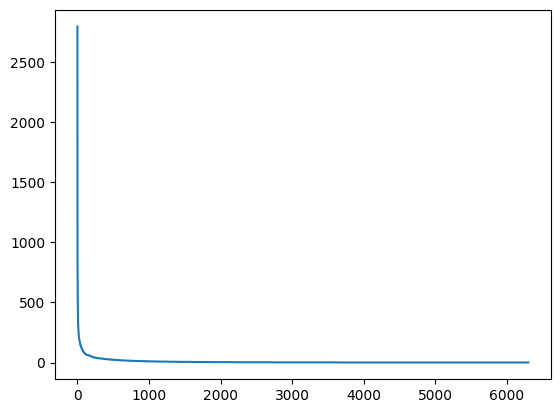

In [ ]:
word_frequency.loc[:, 'count'].plot()

Remove words that appear less than 10 times (use your own judgment for this number. 10 is my rule of thumb).

In [ ]:
word_frequency_s = word_frequency.loc[word_frequency['count'] >= 10,:]
word_frequency_s

,lemma,count
0,China,2796
1,comment,1034
2,say,817
3,chinese,653
4,report,641
...,...,...
1077,Force,10
1078,preparation,10
1079,cut,10
1080,site,10


Then, keep only the selected terms in the dataset.

In [ ]:
text_ling_s = text_ling_s.loc[text_ling_s.lemma.isin(word_frequency_s.lemma), :]
text_ling_s

,token,lower,lemma,pos,stopword,id
3,New,new,New,PROPN,False,28449
7,President,president,President,PROPN,False,28449
8,Xi,xi,Xi,PROPN,False,28449
9,Jinping,jinping,Jinping,PROPN,False,28449
13,received,received,receive,VERB,False,28449
...,...,...,...,...,...,...
124503,comment,comment,comment,NOUN,False,30963
124508,possible,possible,possible,ADJ,False,30964
124517,suspects,suspects,suspect,NOUN,False,30964
124521,China,china,China,PROPN,False,30964


Re-format the selected linguistic feature

In [ ]:
docs = text_ling_s.groupby('id')['lemma'].apply(list).reset_index()
docs

,id,lemma
0,28449,"[New, President, Xi, Jinping, receive, interna..."
1,28450,"[recently, China, announce, decision, manage, ..."
2,28451,"[pay, close, attention, China, communication, ..."
3,28452,"[russian, President, Vladimir, Putin, invite, ..."
4,28453,"[accord, report, President, Lula, January, rec..."
...,...,...
2435,30960,"[interview, news, agency, russian, Foreign, Mi..."
2436,30961,"[spokesperson, local, armed, group, Myanmar, t..."
2437,30962,"[report, spokesperson, Philippines, say, gover..."
2438,30963,"[learn, break, Myanmar, December, cause, casua..."


### 3. BoW Model: Preparation for Topic Modelling

**sklearn**

To convert the dataset into the matrix we need, we import a library of sklearn.

More info at: https://scikit-learn.org/stable/

It is THE most popular Python library for Machine Learning. So popular that you can write it on your resume! It can handle a variety of data, included text data. For now, we use it to turn text into a BoW table. We will use it for many works in future lectures


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

This CountVectorizer function by default takes raw text and tokenize it with a simple tokenizer. Defining the “dummy” function and setting tokenizer and preprocessor as dummy DISABLES it.

Why? We have already tokenized and cleaned our text.


In [ ]:
def dummy(X):
  return X
vectorizer = CountVectorizer(tokenizer = dummy, preprocessor = dummy)
docs_bow = vectorizer.fit_transform(docs.lemma)


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Take a look at the BoW we created!

In [ ]:
docs_bow

<2440x1082 sparse matrix of type '<class 'numpy.int64'>'
	with 39901 stored elements in Compressed Sparse Row format>

In [ ]:
docs_bow.toarray()[:20, :20]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
docs_vocab = vectorizer.get_feature_names_out() # Get the vocabulary
docs_vocab.tolist()[:20]

['$',
 '%',
 '-',
 '10th',
 'APEC',
 'ASEAN',
 'AUKUS',
 'Act',
 'Advisor',
 'Affairs',
 'Afghanistan',
 'Africa',
 'African',
 'Agency',
 'Al',
 'Ambassador',
 'America',
 'American',
 'Antony',
 'April']

In [ ]:
len(docs_vocab)

1082

Now, you have successfully turned text into numbers!